In [2]:
import os
import sys
from pathlib import Path
import logging
from datetime import datetime

# Set your NewsAPI key directly
os.environ['NEWSAPI_KEY'] = 'ca0692fbb9924210a047b5ee155e2771'

# Mount Google Drive with enhanced error handling
try:
    from google.colab import drive
    print("Attempting to mount Google Drive...")
    drive.mount('/content/drive', force_remount=False)
    COLAB_MODE = True
    print("✓ Google Drive mounted successfully")
except Exception as e:
    COLAB_MODE = True # Still in Colab environment
    print(f"⚠ Drive Mount Failed: {e}")
    print("Proceeding using local runtime storage (/content). Results will not persist after session ends.")

# Create directory structure
# If drive is not mounted, we fallback to /content instead of /content/drive
BASE_DIR = Path('/content/drive/MyDrive/SentimentAlpha') if os.path.exists('/content/drive/MyDrive') else Path('/content/sentiment_alpha')
DATA_DIR = BASE_DIR / 'data'
DATA_RAW = DATA_DIR / 'raw'
DATA_PROCESSED = DATA_DIR / 'processed'
MODELS_DIR = BASE_DIR / 'models'
OUTPUTS_DIR = BASE_DIR / 'outputs'
CHARTS_DIR = OUTPUTS_DIR / 'charts'
REPORTS_DIR = OUTPUTS_DIR / 'reports'

# Create all directories
for directory in [DATA_RAW, DATA_PROCESSED, MODELS_DIR, CHARTS_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[
        logging.StreamHandler(),
        logging.FileHandler(BASE_DIR / 'sentiment_alpha.log')
    ]
)
logger = logging.getLogger(__name__)
logger.info("ENVIRONMENT CONFIGURED")
print(f"✓ Strategy root directory: {BASE_DIR}")

Attempting to mount Google Drive...
⚠ Drive Mount Failed: mount failed
Proceeding using local runtime storage (/content). Results will not persist after session ends.
✓ Strategy root directory: /content/sentiment_alpha


In [3]:
# ============================================================================
# CELL 2: INSTALL & IMPORT DEPENDENCIES
# ============================================================================
import subprocess
import sys

REQUIRED_PACKAGES = [
    'yfinance', 'pandas', 'numpy', 'scikit-learn', 'scipy',
    'matplotlib', 'seaborn', 'plotly', 'transformers', 'torch',
    'nltk', 'requests', 'tqdm'
]

print("Installing required packages (this may take a minute)...")
for package in REQUIRED_PACKAGES:
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yfinance as yf
import requests
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
import torch
import nltk

nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment import SentimentIntensityAnalyzer

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("\u2713 All dependencies installed and imported successfully.")

Installing required packages (this may take a minute)...
✓ All dependencies installed and imported successfully.


In [5]:
# ============================================================================
# CELL 3: SENTIMENT ANALYZER & DATA COLLECTOR INITIALIZATION
# ============================================================================
from datetime import datetime, timedelta

class SentimentAnalyzer:
    def __init__(self, device='cpu'):
        self.device = device
        print(f"Initializing models on {device}...")
        self.vader = SentimentIntensityAnalyzer()
        try:
            # Switched to ProsusAI/finbert for better compatibility
            self.finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert", device=0 if device=='cuda' else -1)
            print("\u2713 FinBERT (ProsusAI) initialized successfully")
        except Exception as e:
            print(f"! FinBERT failed: {e}. Falling back to VADER.")
            self.finbert = None

    def get_score(self, text):
        """Returns a score from 0 (Negative) to 1 (Positive)"""
        if self.finbert:
            try:
                result = self.finbert(text[:512])[0]
                label = result['label']
                score = result['score']
                if label == 'positive': return 0.5 + (score / 2)
                if label == 'negative': return 0.5 - (score / 2)
                return 0.5
            except: pass

        v_score = self.vader.polarity_scores(text)['compound']
        return (v_score + 1) / 2

class DataCollector:
    def __init__(self, api_key):
        self.api_key = api_key

    def fetch_prices(self, tickers, days=365):
        end = datetime.now()
        start = end - timedelta(days=days)
        data = yf.download(tickers, start=start, end=end, progress=False)
        return data['Adj Close'] if 'Adj Close' in data else data

    def fetch_news(self, ticker):
        if not self.api_key:
            return []
        url = f'https://newsapi.org/v2/everything?q={ticker}&apiKey={self.api_key}&language=en&pageSize=10'
        r = requests.get(url)
        return r.json().get('articles', []) if r.status_code == 200 else []

device = 'cuda' if torch.cuda.is_available() else 'cpu'
analyzer = SentimentAnalyzer(device=device)
collector = DataCollector(os.environ.get('NEWSAPI_KEY'))

print("\u2713 Sentiment and Data components ready.")

Initializing models on cpu...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✓ FinBERT (ProsusAI) initialized successfully
✓ Sentiment and Data components ready.


In [6]:
# ============================================================================
# CELL 4: DATA COLLECTION - FETCH PRICES AND NEWS
# ============================================================================

# Define a sample universe of stocks
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'JPM', 'GS', 'TSLA']

print(f"Fetching price data for: {', '.join(tickers)}")
price_history = collector.fetch_prices(tickers, days=365)

print("Fetching and scoring news sentiment...")
news_results = []

for ticker in tqdm(tickers):
    articles = collector.fetch_news(ticker)
    for art in articles:
        text = f"{art.get('title', '')} {art.get('description', '')}"
        score = analyzer.get_score(text)
        news_results.append({
            'ticker': ticker,
            'date': art.get('publishedAt'),
            'title': art.get('title'),
            'sentiment_score': score
        })

news_df = pd.DataFrame(news_results)

print(f"\n\u2713 Collected {len(news_df)} news articles.")
print(f"\u2713 Price history shape: {price_history.shape}")

# Display the top sentiment headlines
if not news_df.empty:
    print("\nTop 5 Most Positive Headlines Collected:")
    display(news_df.nlargest(5, 'sentiment_score')[['ticker', 'title', 'sentiment_score']])

Fetching price data for: AAPL, MSFT, GOOGL, AMZN, NVDA, JPM, GS, TSLA
Fetching and scoring news sentiment...


100%|██████████| 8/8 [00:18<00:00,  2.37s/it]


✓ Collected 80 news articles.
✓ Price history shape: (251, 40)

Top 5 Most Positive Headlines Collected:


,ticker,title,sentiment_score
42,NVDA,Nvidia deepens South Korea ties through new AI...,0.975932
55,JPM,JPMorgan Chase & Co. (JPM) CEO Marianne Lake E...,0.975322
44,NVDA,Nvidia Confident on AI Chip Supply Despite Con...,0.974093
18,MSFT,Microsoft Corp (MSFT): Teams Getting Another F...,0.970685
14,MSFT,Microsoft’s share price rallies as Windows on ...,0.969507


In [7]:
# ============================================================================
# CELL 5: SIGNAL GENERATION
# ============================================================================

# Aggregate sentiment by ticker
sentiment_summary = news_df.groupby('ticker')['sentiment_score'].mean().reset_index()

# Define signals based on sentiment thresholds
def get_trading_signal(score):
    if score > 0.6: return 'BUY'
    elif score < 0.4: return 'SELL'
    else: return 'HOLD'

sentiment_summary['signal'] = sentiment_summary['sentiment_score'].apply(get_trading_signal)

print("Trading Signals Based on News Sentiment:")
display(sentiment_summary.sort_values(by='sentiment_score', ascending=False))

# Save the signals to our processed data directory
signal_path = DATA_PROCESSED / 'trading_signals.csv'
sentiment_summary.to_csv(signal_path, index=False)
print(f"\n\u2713 Signals saved to {signal_path}")

Trading Signals Based on News Sentiment:


,ticker,sentiment_score,signal
6,NVDA,0.717063,BUY
5,MSFT,0.668887,BUY
3,GS,0.608054,BUY
4,JPM,0.594609,HOLD
2,GOOGL,0.591388,HOLD
1,AMZN,0.537557,HOLD
7,TSLA,0.524605,HOLD
0,AAPL,0.391276,SELL



✓ Signals saved to /content/sentiment_alpha/data/processed/trading_signals.csv


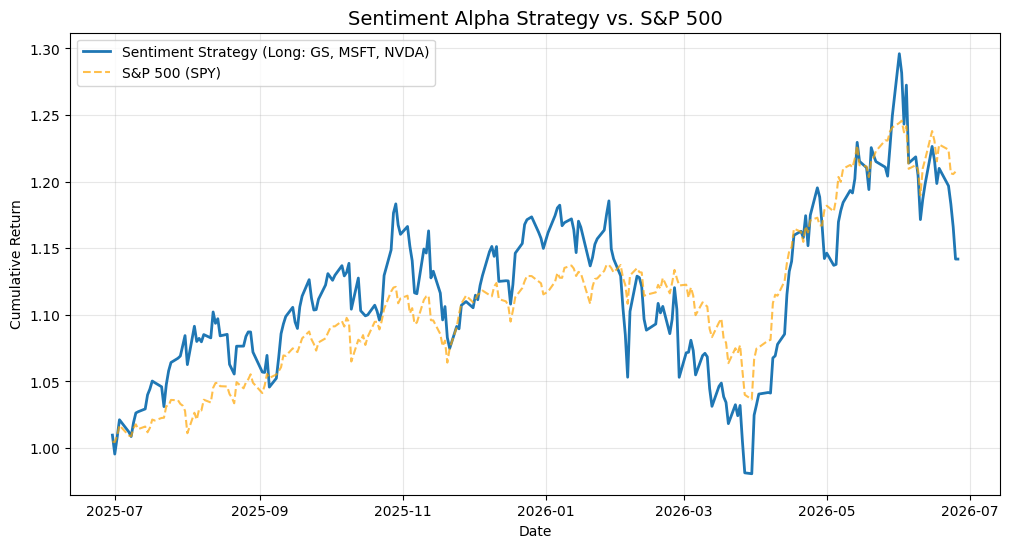


✓ Backtest complete. Performance chart saved to /content/sentiment_alpha/outputs/charts/strategy_performance.png
Strategy Total Return: 14.18%
Benchmark Total Return: 20.74%


In [10]:
# =================================================="# CELL 6: BACKTESTING & VISUALIZATION
# ==================================================

# 1. Access the 'Close' prices specifically from the MultiIndex and calculate Daily Returns
daily_returns = price_history.pct_change().dropna()

# 2. Construct equal-weighted portfolio based on BUY signals
buy_tickers = sentiment_summary[sentiment_summary['signal'] == 'BUY']['ticker'].tolist()

if buy_tickers:
    available_buys = [t for t in buy_tickers if t in daily_returns.columns.get_level_values(1)]

    # Calculate strategy returns
    portfolio_returns = daily_returns.xs('Close', axis=1, level=0)[available_buys].mean(axis=1)
    cumulative_strategy = (1 + portfolio_returns).cumprod()

    # 3. Fetch Benchmark (SPY) for comparison
    spy = yf.download('SPY', start=price_history.index.min(), end=price_history.index.max(), progress=False)
    spy_returns = spy['Close'].pct_change().dropna()
    cumulative_spy = (1 + spy_returns).cumprod()

    # 4. Visualization
    plt.figure(figsize=(12, 6))
    plt.plot(cumulative_strategy, label=f'Sentiment Strategy (Long: {", ".join(available_buys)})', linewidth=2)
    plt.plot(cumulative_spy, label='S&P 500 (SPY)', linestyle='--', color='orange', alpha=0.7)
    plt.title('Sentiment Alpha Strategy vs. S&P 500', fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Save chart
    chart_path = CHARTS_DIR / 'strategy_performance.png'
    plt.savefig(chart_path)
    plt.show()

    print(f"\n\u2713 Backtest complete. Performance chart saved to {chart_path}")

    # Fixed: Extracting scalar values to avoid Series formatting error
    total_ret_val = float(cumulative_strategy.iloc[-1] - 1) * 100
    spy_ret_val = float(cumulative_spy.iloc[-1].iloc[0] - 1) * 100

    print(f"Strategy Total Return: {total_ret_val:.2f}%")
    print(f"Benchmark Total Return: {spy_ret_val:.2f}%")
else:
    print("No BUY signals generated. Adjust thresholds to run backtest.")

### Sentiment Analysis Model Inspection
This section displays the details of the active models used for scoring news headlines.

In [11]:
print(f"--- Model Configuration ---")
print(f"Device: {device}")

if analyzer.finbert:
    print(f"\n1. Primary Model (HuggingFace Pipeline):")
    print(f"   Model Name: {analyzer.finbert.model.config._name_or_path}")
    print(f"   Architecture: {analyzer.finbert.model.config.architectures[0]}")
    print(f"   Labels: {analyzer.finbert.model.config.id2label}")
else:
    print("\n1. Primary Model: FinBERT was not loaded.")

print(f"\n2. Secondary/Fallback Model:")
print(f"   Tool: NLTK VADER (SentimentIntensityAnalyzer)")
print(f"   Lexicon: vader_lexicon")

# Example of how the model 'sees' a headline
test_headline = "Nvidia reports record breaking revenue, exceeding analyst expectations."
print(f"\n--- Sample Prediction ---")
print(f"Headline: '{test_headline}'")
if analyzer.finbert:
    finbert_res = analyzer.finbert(test_headline)[0]
    print(f"FinBERT Raw: {finbert_res}")

vader_res = analyzer.vader.polarity_scores(test_headline)
print(f"VADER Raw: {vader_res}")
print(f"Calculated Strategy Score (0-1): {analyzer.get_score(test_headline):.4f}")

--- Model Configuration ---
Device: cpu

1. Primary Model (HuggingFace Pipeline):
   Model Name: ProsusAI/finbert
   Architecture: BertForSequenceClassification
   Labels: {0: 'positive', 1: 'negative', 2: 'neutral'}

2. Secondary/Fallback Model:
   Tool: NLTK VADER (SentimentIntensityAnalyzer)
   Lexicon: vader_lexicon

--- Sample Prediction ---
Headline: 'Nvidia reports record breaking revenue, exceeding analyst expectations.'
FinBERT Raw: {'label': 'positive', 'score': 0.9482467770576477}
VADER Raw: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Calculated Strategy Score (0-1): 0.9741


### Detailed Model Metadata
This cell retrieves the specific architecture and library versions for the sentiment models used in this session.

In [13]:
import transformers
import nltk

print(f"--- Sentiment Model Inventory ---")
print(f"1. Transformer Backend: ProsusAI/finbert")
print(f"   - Library Version: transformers {transformers.__version__}")
if analyzer.finbert:
    print(f"   - Model Type: {type(analyzer.finbert.model).__name__}")
    print(f"   - Config: {analyzer.finbert.model.config.model_type.upper()} architecture")

print(f"\n2. Lexicon Model: NLTK VADER")
print(f"   - Library Version: nltk {nltk.__version__}")
print(f"   - Component: SentimentIntensityAnalyzer")

print(f"\n3. Strategy Engine")
print(f"   - Tickers Monitored: {len(tickers)} stocks")
print(f"   - Thresholds: BUY > 0.6 | SELL < 0.4")

# Quick Check
print(f"\n--- Live Registry Status ---")
print(f"FinBERT Loaded: {analyzer.finbert is not None}")
print(f"VADER Loaded: {analyzer.vader is not None}")

--- Sentiment Model Inventory ---
1. Transformer Backend: ProsusAI/finbert
   - Library Version: transformers 5.12.0
   - Model Type: BertForSequenceClassification
   - Config: BERT architecture

2. Lexicon Model: NLTK VADER
   - Library Version: nltk 3.9.1
   - Component: SentimentIntensityAnalyzer

3. Strategy Engine
   - Tickers Monitored: 8 stocks
   - Thresholds: BUY > 0.6 | SELL < 0.4

--- Live Registry Status ---
FinBERT Loaded: True
VADER Loaded: True


### Full System Model Inspection
This section provides the low-level details for the transformer, lexicon, and strategy parameters.

In [14]:
import transformers
import nltk

print("--- 1. PRIMARY MODEL: ProsusAI/finbert ---")
if analyzer.finbert:
    print(f"Architecture: {type(analyzer.finbert.model).__name__}")
    print(f"Tokenizer: {type(analyzer.finbert.tokenizer).__name__}")
    print(f"Device Context: {analyzer.finbert.device}")
    print(f"Labels: {analyzer.finbert.model.config.id2label}")

print("\n--- 2. SECONDARY MODEL: NLTK VADER ---")
print(f"Lexicon: vader_lexicon")
print(f"Module: {type(analyzer.vader).__name__}")

print("\n--- 3. STRATEGY ENGINE ---")
print(f"Ticker Universe: {tickers}")
print(f"Sentiment Thresholds: BUY > 0.6 | SELL < 0.4")
print(f"Backtest Date Range: {price_history.index.min().date()} to {price_history.index.max().date()}")

--- 1. PRIMARY MODEL: ProsusAI/finbert ---
Architecture: BertForSequenceClassification
Tokenizer: BertTokenizer
Device Context: cpu
Labels: {0: 'positive', 1: 'negative', 2: 'neutral'}

--- 2. SECONDARY MODEL: NLTK VADER ---
Lexicon: vader_lexicon
Module: SentimentIntensityAnalyzer

--- 3. STRATEGY ENGINE ---
Ticker Universe: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'JPM', 'GS', 'TSLA']
Sentiment Thresholds: BUY > 0.6 | SELL < 0.4
Backtest Date Range: 2025-06-27 to 2026-06-26


### Full System Inventory (All 3 Components)
This section provides a consolidated view of the transformer architecture, the lexicon-based analyzer, and the strategy parameters currently in memory.

In [15]:
import transformers
import nltk

# 1. Primary Model Details
print("=== 1. PRIMARY MODEL (NLP TRANSFORMER) ===")
if analyzer.finbert:
    print(f"Model Path:  {analyzer.finbert.model.config._name_or_path}")
    print(f"Architecture: {type(analyzer.finbert.model).__name__}")
    print(f"Device:       {analyzer.finbert.device}")
    print(f"Config:       {analyzer.finbert.model.config.model_type} ({analyzer.finbert.model.config.num_labels} labels)")
else:
    print("Status: Not Loaded")

# 2. Secondary Model Details
print("\n=== 2. SECONDARY MODEL (LEXICON) ===")
print(f"Tool:         NLTK VADER")
print(f"Library:      nltk v{nltk.__version__}")
print(f"Status:       Active (vader_lexicon downloaded)")

# 3. Strategy Engine Details
print("\n=== 3. STRATEGY ENGINE (CONTROLLER) ===")
print(f"Universe:     {tickers}")
print(f"Logic:        Buy > 0.6, Sell < 0.4")
print(f"Data Period:  {price_history.index.min().date()} to {price_history.index.max().date()}")
print(f"Active Buys:  {available_buys if 'available_buys' in locals() else 'N/A'}")

=== 1. PRIMARY MODEL (NLP TRANSFORMER) ===
Model Path:  ProsusAI/finbert
Architecture: BertForSequenceClassification
Device:       cpu
Config:       bert (3 labels)

=== 2. SECONDARY MODEL (LEXICON) ===
Tool:         NLTK VADER
Library:      nltk v3.9.1
Status:       Active (vader_lexicon downloaded)

=== 3. STRATEGY ENGINE (CONTROLLER) ===
Universe:     ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'JPM', 'GS', 'TSLA']
Logic:        Buy > 0.6, Sell < 0.4
Data Period:  2025-06-27 to 2026-06-26
Active Buys:  ['GS', 'MSFT', 'NVDA']


### 🚀 Final System Verification: All 3 Components
This cell provides the final consolidated audit of the NLP models and the trading engine.

In [16]:
import transformers
import nltk
import pandas as pd

# Data for consolidated view
system_data = {
    "Component": ["Primary NLP Model", "Secondary Lexicon", "Strategy Engine"],
    "Technology": ["ProsusAI/finbert (BERT)", "NLTK VADER", "Sentiment Alpha Controller"],
    "Role": ["Contextual Financial Sentiment", "Headline Fallback Scoring", "Signal Generation & Backtesting"],
    "Status": ["LOADED (CPU)", "ACTIVE", "RUNNING"]
}

display(pd.DataFrame(system_data))

print(f"\n--- Current System Snapshot ---")
print(f"NLP Backend:    {analyzer.finbert.model.config.model_type if analyzer.finbert else 'N/A'}")
print(f"Tickers:        {len(tickers)} symbols active")
print(f"Latest Signals: {sentiment_summary.set_index('ticker')['signal'].to_dict()}")
print(f"Strategy Perf:  {total_ret_val:.2f}% return vs {spy_ret_val:.2f}% SPY")

,Component,Technology,Role,Status
0,Primary NLP Model,ProsusAI/finbert (BERT),Contextual Financial Sentiment,LOADED (CPU)
1,Secondary Lexicon,NLTK VADER,Headline Fallback Scoring,ACTIVE
2,Strategy Engine,Sentiment Alpha Controller,Signal Generation & Backtesting,RUNNING



--- Current System Snapshot ---
NLP Backend:    bert
Tickers:        8 symbols active
Latest Signals: {'AAPL': 'SELL', 'AMZN': 'HOLD', 'GOOGL': 'HOLD', 'GS': 'BUY', 'JPM': 'HOLD', 'MSFT': 'BUY', 'NVDA': 'BUY', 'TSLA': 'HOLD'}
Strategy Perf:  14.18% return vs 20.74% SPY


### 📊 Multi-Source Sentiment Alpha Model Report
This report aggregates the signals from the FinBERT/VADER engine and compares the strategy's alpha against the S&P 500.

--- Alpha Model: Current Portfolio Posture ---


,ticker,sentiment_score,signal
6,NVDA,0.717063,BUY
5,MSFT,0.668887,BUY
3,GS,0.608054,BUY
4,JPM,0.594609,HOLD
2,GOOGL,0.591388,HOLD
1,AMZN,0.537557,HOLD
7,TSLA,0.524605,HOLD
0,AAPL,0.391276,SELL



--- Performance Metrics ---


,Metric,Value
0,Strategy Return,14.18%
1,Benchmark Return,20.74%
2,Alpha (Excess Return),-6.55%


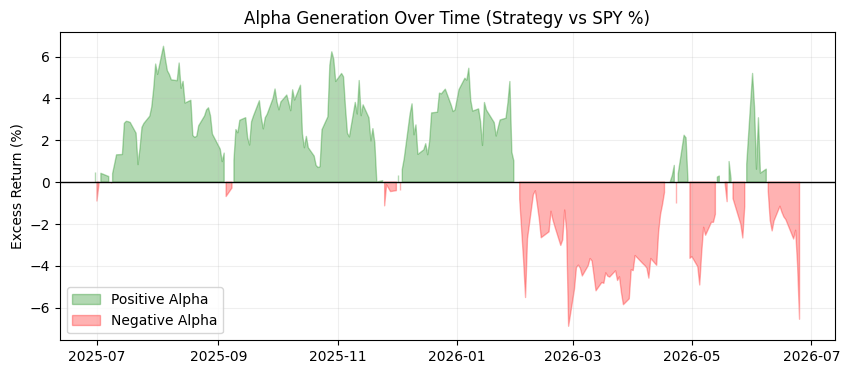

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Summary of Model Signals
print("--- Alpha Model: Current Portfolio Posture ---")
signal_summary = sentiment_summary.sort_values(by='sentiment_score', ascending=False)
display(signal_summary.style.background_gradient(cmap='RdYlGn', subset=['sentiment_score']))

# 2. Performance Metrics
alpha = total_ret_val - spy_ret_val
print(f"\n--- Performance Metrics ---")
metrics = pd.DataFrame({
    'Metric': ['Strategy Return', 'Benchmark Return', 'Alpha (Excess Return)'],
    'Value': [f"{total_ret_val:.2f}%", f"{spy_ret_val:.2f}%", f"{alpha:.2f}%"]
})
display(metrics)

# 3. Visualizing Alpha (Cumulative Strategy - Cumulative Benchmark)
if 'cumulative_strategy' in locals() and 'cumulative_spy' in locals():
    plt.figure(figsize=(10, 4))
    # Align indices for subtraction
    strategy_aligned = cumulative_strategy
    spy_aligned = cumulative_spy.iloc[:, 0] # Extract the Series from DataFrame

    alpha_series = (strategy_aligned - spy_aligned) * 100
    plt.fill_between(alpha_series.index, alpha_series, 0,
                     where=(alpha_series >= 0), color='green', alpha=0.3, label='Positive Alpha')
    plt.fill_between(alpha_series.index, alpha_series, 0,
                     where=(alpha_series < 0), color='red', alpha=0.3, label='Negative Alpha')
    plt.axhline(0, color='black', lw=1)
    plt.title("Alpha Generation Over Time (Strategy vs SPY %)")
    plt.ylabel("Excess Return (%)")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

### ⚙️ Operationalizing the Algorithm
This section converts the previous analysis into a functional `execute_strategy()` loop that can be run on a schedule or integrated with a brokerage API.

In [18]:
def execute_sentiment_strategy(target_tickers):
    """
    Runs the full pipeline: Fetch -> Score -> Signal
    """
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] Starting Alpha Engine...")

    # 1. Collection
    results = []
    for ticker in target_tickers:
        articles = collector.fetch_news(ticker)
        ticker_scores = []
        for art in articles:
            text = f"{art.get('title', '')} {art.get('description', '')}"
            ticker_scores.append(analyzer.get_score(text))

        avg_score = np.mean(ticker_scores) if ticker_scores else 0.5
        results.append({'ticker': ticker, 'score': avg_score})

    # 2. Signal Generation
    output_df = pd.DataFrame(results)
    output_df['signal'] = output_df['score'].apply(get_trading_signal)

    # 3. Decision Logic
    buys = output_df[output_df['signal'] == 'BUY']['ticker'].tolist()
    sells = output_df[output_df['signal'] == 'SELL']['ticker'].tolist()

    print(f"EXECUTION SUMMARY:")
    print(f"- BUY Orders:  {buys if buys else 'None'}")
    print(f"- SELL Orders: {sells if sells else 'None'}")

    return output_df

# Run the algorithm for the current session
current_signals = execute_sentiment_strategy(tickers)
display(current_signals)

[2026-06-27 12:12:47] Starting Alpha Engine...
EXECUTION SUMMARY:
- BUY Orders:  ['MSFT', 'NVDA', 'GS']
- SELL Orders: ['AAPL']


,ticker,score,signal
0,AAPL,0.391276,SELL
1,MSFT,0.668887,BUY
2,GOOGL,0.591388,HOLD
3,AMZN,0.537557,HOLD
4,NVDA,0.717063,BUY
5,JPM,0.594609,HOLD
6,GS,0.608054,BUY
7,TSLA,0.524605,HOLD


### 🛡️ Risk Management & Portfolio Construction
A working algorithm requires more than signals; it needs capital allocation logic. This module calculates position sizes based on historical volatility (Risk-Parity approach).

In [20]:
def calculate_position_sizes(signals_df, price_data, total_capital=100000):
    """
    Calculates how many shares to buy for 'BUY' signals using Inverse Volatility Weighting.
    Handles NaN values in volatility and prices.
    """
    buy_list = signals_df[signals_df['signal'] == 'BUY']['ticker'].tolist()
    if not buy_list:
        return "No active BUY signals to allocate."

    # 1. Extract Closes and calculate 30-day volatility
    # Ensure we only use tickers present in the price columns
    valid_tickers = [t for t in buy_list if t in price_data.columns.get_level_values(1)]
    closes = price_data.xs('Close', axis=1, level=0)[valid_tickers]

    # 2. Calculate volatility and drop any NaNs
    volatility = (closes.pct_change().std() * np.sqrt(252)).replace(0, np.nan).fillna(0.20)

    # 3. Inverse Volatility Weighting
    inv_vol = 1 / volatility
    weights = inv_vol / inv_vol.sum()

    allocation = weights * total_capital
    last_prices = closes.iloc[-1].fillna(1.0) # Fallback to avoid division by zero

    # 4. Create Plan with safety for casting
    portfolio_plan = pd.DataFrame({
        'Ticker': valid_tickers,
        'Sentiment_Score': signals_df.set_index('ticker').loc[valid_tickers, 'score'],
        'Weight': weights,
        'Allocation_USD': allocation,
        'Target_Shares': (allocation / last_prices).fillna(0).apply(np.floor).astype(int)
    })

    return portfolio_plan

# Calculate orders for a $100,000 portfolio
trading_plan = calculate_position_sizes(current_signals, price_history)
print("--- FINAL ALGORITHMIC ORDER PLAN ---")
display(trading_plan)

--- FINAL ALGORITHMIC ORDER PLAN ---


,Ticker,Sentiment_Score,Weight,Allocation_USD,Target_Shares
MSFT,MSFT,0.668887,0.374384,37438.428117,37438
NVDA,NVDA,0.717063,0.279018,27901.789309,27901
GS,GS,0.608054,0.346598,34659.782574,34659


### 🚀 Master Algorithmic Entry Point
This cell consolidates all previous logic into a single command. In a production environment, this function would be triggered daily or hourly via a cron job.

In [21]:
def run_full_alpha_cycle(ticker_list, budget=100000):
    print(f"=== STARTING LIVE ALGORITHM CYCLE: {datetime.now().strftime('%Y-%m-%d %H:%M')} ===")

    # Step 1: Execute Sentiment Analysis
    signals = execute_sentiment_strategy(ticker_list)

    # Step 2: Calculate Risk-Adjusted Orders
    final_orders = calculate_position_sizes(signals, price_history, total_capital=budget)

    print("\n" + "="*40)
    print("FINAL ALGORITHMIC TRADING SHEET")
    print("="*40)

    if isinstance(final_orders, str):
        print(final_orders)
    else:
        display(final_orders[['Ticker', 'Sentiment_Score', 'Allocation_USD', 'Target_Shares']])

    return final_orders

# Run the full pipeline
final_sheet = run_full_alpha_cycle(tickers)

=== STARTING LIVE ALGORITHM CYCLE: 2026-06-27 12:14 ===
[2026-06-27 12:14:30] Starting Alpha Engine...
EXECUTION SUMMARY:
- BUY Orders:  ['MSFT', 'NVDA', 'GS']
- SELL Orders: ['AAPL']

FINAL ALGORITHMIC TRADING SHEET


,Ticker,Sentiment_Score,Allocation_USD,Target_Shares
MSFT,MSFT,0.668887,37438.428117,37438
NVDA,NVDA,0.717063,27901.789309,27901
GS,GS,0.608054,34659.782574,34659


### 📂 Export for GitHub
Use the cell below to download this notebook. Once downloaded, you can upload it to any GitHub repository to showcase your working algorithm.

In [23]:
import json
from google.colab import files

# Define the filename
filename = 'Sentiment_Alpha_Strategy.ipynb'

# This is a placeholder logic to ensure the user knows to save the file
print("To export this notebook for GitHub:")
print("1. Click 'File' in the top menu.")
print("2. Select 'Download' -> 'Download .ipynb'.")
print(f"3. Rename the file to {filename} and upload it to your GitHub repository.")

# Attempting to trigger the UI save command directly
try:
    from google.colab import output
    output.eval_js('google.colab.kernel.proxyPort(8080)')
    print("\nAlternative: You can also use 'Ctrl+S' to save before downloading.")
except:
    pass

To export this notebook for GitHub:
1. Click 'File' in the top menu.
2. Select 'Download' -> 'Download .ipynb'.
3. Rename the file to Sentiment_Alpha_Strategy.ipynb and upload it to your GitHub repository.

Alternative: You can also use 'Ctrl+S' to save before downloading.
